In [1]:
import os ;\
import site ;\
import sys ;\
os.system('mkdir -p ' + site.getusersitepackages()) ;\
os.system('ln -sf "/Applications/Wind API.app/Contents/python/WindPy.py"' + ' ' + site.getusersitepackages()) ;\
os.system('ln -sf "/Applications/Wind API.app/Contents/python/WindPy.py"' + ' ' + site.getsitepackages()[0]) ;\
os.system('rm -rf ~/.Wind') ;\
os.system('ln -sf ~/Library/Containers/com.wind.mac.api/Data/.Wind ~/.Wind') ;\
print("Current Python Version: " + sys.version) ;\
print("Current Python Env: " + sys.executable) ;\
print("WindPy installed at: " + site.getusersitepackages()) ;\
print("WindPy installed at: " + site.getsitepackages()[0])

Current Python Version: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 11:23:37) [Clang 14.0.6 ]
Current Python Env: /opt/anaconda3/bin/python
WindPy installed at: /Users/yinzi/.local/lib/python3.13/site-packages
WindPy installed at: /opt/anaconda3/lib/python3.13/site-packages


In [2]:
from WindPy import *

ret = w.start()
print(ret)

ret = w.isconnected()
print(ret)

#test WSS function
ret = w.wss("000001.SZ", "sec_name","")
print(ret)

26.1.7.60050
Wind.Cosmos.Base V1.8 compiled time is Sep 28 2025, BuildType:Release, CPUArch:X64, GCC Version:Apple LLVM 13.0.0 (clang-1300.0.29.30)
Welcome to use Wind Quant API for Python (WindPy)!

COPYRIGHT (C) 2021 WIND INFORMATION CO., LTD. ALL RIGHTS RESERVED.
IN NO CIRCUMSTANCE SHALL WIND BE RESPONSIBLE FOR ANY DAMAGES OR LOSSES CAUSED BY USING WIND QUANT API FOR Python.
.ErrorCode=0
.Data=[OK!]
True
.ErrorCode=0
.Codes=[000001.SZ]
.Fields=[SEC_NAME]
.Times=[20260704 22:14:48]
.Data=[[平安银行]]


In [3]:
import sys
print(sys.executable)

/opt/anaconda3/bin/python


In [4]:
import pandas as pd
import numpy as np

# TEST
w.start()

data=w.wsd("000002.SZ", "close", "2026-07-02", "2026-07-02", "")
print(data)

Welcome to use Wind Quant API for Python (WindPy)!

COPYRIGHT (C) 2021 WIND INFORMATION CO., LTD. ALL RIGHTS RESERVED.
IN NO CIRCUMSTANCE SHALL WIND BE RESPONSIBLE FOR ANY DAMAGES OR LOSSES CAUSED BY USING WIND QUANT API FOR Python.
.ErrorCode=0
.Codes=[000002.SZ]
.Fields=[CLOSE]
.Times=[20260702]
.Data=[[3.06]]


In [5]:
# 中证500/800/1000/2000 国证1000/2000为基准的主动量化和指数增强基金（aum大于2亿，成立时间大于一年）

# fund code for 中证500 
fund_codes_SH500 = [
    "006729.OF", "006730.OF", "014305.OF", "014306.OF", "004945.OF", "561550.OF", "001556.OF", "001557.OF", "159610.OF",
    "006682.OF", "016935.OF", "012080.OF", "012081.OF", "002316.OF", "006048.OF", "007413.OF", "003016.OF", "014344.OF", "014155.OF", "003578.OF",
    "003986.OF", "014156.OF", "006593.OF", "006594.OF", "502000.OF", "009300.OF", "015508.OF", "005994.OF", "002906.OF", "007089.OF", "002907.OF", "005062.OF",
    "000478.OF", "161017.OF", "004192.OF", "013332.OF", "004193.OF", "001050.OF", "016854.OF", "021186.OF"
]

# fund code for 中证800
fund_codes_SH800 = ["016276.OF", "022513.OF", "010673.OF"]

# fund code for 中证1000
fund_codes_SH1000 = [
    "018013.OF", "018014.OF", "015466.OF", "017094.OF", "017095.OF", "017953.OF", "017954.OF", "019240.OF", "019241.OF", "005313.OF",
    "017644.OF", "005314.OF", "017645.OF", "017846.OF", "006165.OF", "015867.OF", "017847.OF", "006166.OF", "015868.OF", "019555.OF", "014201.OF",
    "014202.OF", "018157.OF", "018158.OF", "159680.OF", "161039.OF", "013331.OF", "017919.OF", "017920.OF", "016936.OF", "016937.OF", "016785.OF", "016942.OF", "016943.OF",
    "004194.OF", "004195.OF", "015784.OF"]
    
# fund code for 中证2000
fund_codes_SH2000 = ["019918.OF", "019919.OF", "159552.OF"]

# no fund for 国证1000 

# fund code for 国证2000
fund_codes_GZ2000 = ["019318.OF", "019319.OF", "018653.OF"]

In [6]:
w.wss("013332.OF", "NAV_acc", "")

.ErrorCode=0
.Codes=[013332.OF]
.Fields=[NAV_ACC]
.Times=[20260704 22:14:49]
.Data=[[3.072]]

In [7]:
# codes for the index 中证500/800/1000/2000 国证2000
index_codes = ["000905.SH", "000906.SH", "000852.SH", "932000.CSI", "399303.SZ"]

In [8]:
def get_index_daily_returns(index_code, start_date, end_date, save_path=None):
    error_code, data = w.wsd(index_code, "pct_chg", start_date, end_date, "", usedf=True)

    if error_code != 0:
        print(error_code)
        print(data)
        return None

    if save_path:
        data.to_csv(save_path, index=True)

    return data

In [9]:
def get_fund_nav_data(fund_codes, start_date, end_date, save_path=None):
      w.start()

      error_code, nav_data = w.wsd(
            fund_codes,
            "NAV_acc",  # cumulative NAV: avoids artificial drops on fund distribution dates
            start_date,
            end_date,
            "",
            usedf=True,
      )

      name_error_code, name_data = w.wss(
            fund_codes,
            "sec_name",
            usedf=True,
      )

      if error_code != 0:
            print(error_code)
            print(nav_data)
            return None

      if name_error_code != 0:
            print(name_error_code)
            print(name_data)
            return None

      chart = nav_data.T
      chart.index.name = "fund_code"
      chart.columns = [pd.Timestamp(col).strftime("%Y-%m-%d") for col in chart.columns]

      fund_names = name_data.iloc[:, 0].reindex(chart.index)
      chart = pd.concat([fund_names.rename("fund_name"), chart], axis=1)

      if save_path:
            chart.to_csv(save_path, index=True)

      return chart


def calculate_fund_daily_returns(fund_nav_data, save_path=None):
      if isinstance(fund_nav_data, str):
            fund_nav_data = pd.read_csv(fund_nav_data, index_col=0)
      else:
            fund_nav_data = fund_nav_data.copy()

      fund_names = fund_nav_data["fund_name"]
      nav_data = fund_nav_data.drop(columns=["fund_name"]).copy()
      calculated_returns = nav_data.pct_change(axis=1).dropna(axis=1) * 100
      calculated_returns = pd.concat(
            [fund_names.reindex(calculated_returns.index).rename("fund_name"), calculated_returns],
            axis=1,
      )

      if save_path:
            calculated_returns.to_csv(save_path, index=True)

      return calculated_returns

In [10]:
chart_sh500 = get_fund_nav_data(
    fund_codes_SH500,
    "2025-07-01",
    "2026-07-01",
    save_path="fund_nav_data_sh500.csv",
)

daily_returns_sh500 = calculate_fund_daily_returns(
    chart_sh500,
    save_path="fund_daily_returns_sh500.csv",
)

print(daily_returns_sh500)

Welcome to use Wind Quant API for Python (WindPy)!

COPYRIGHT (C) 2021 WIND INFORMATION CO., LTD. ALL RIGHTS RESERVED.
IN NO CIRCUMSTANCE SHALL WIND BE RESPONSIBLE FOR ANY DAMAGES OR LOSSES CAUSED BY USING WIND QUANT API FOR Python.
                  fund_name  2025-07-02  2025-07-03  2025-07-04  2025-07-07  \
fund_code                                                                     
006729.OF      万家中证500指数增强A   -0.168552    0.354011   -0.244220   -0.032642   
006730.OF      万家中证500指数增强C   -0.166963    0.351210   -0.244431   -0.033413   
014305.OF    华泰柏瑞中证500指数增强A   -0.523032    0.618024   -0.247525   -0.202187   
014306.OF    华泰柏瑞中证500指数增强C   -0.520398    0.616534   -0.250673   -0.204765   
004945.OF      长信中证500指数增强A   -0.262484    0.315810   -0.196760    0.039430   
561550.OF  华泰柏瑞中证500增强策略ETF   -0.528670    0.582584   -0.284524   -0.224192   
001556.OF      天弘中证500指数增强A   -0.757817    0.651073   -0.079859   -0.095908   
001557.OF      天弘中证500指数增强C   -0.757077    0.646766   -0

In [11]:
# get pct_chg using w.wsd of 000905.SH from 2025-07-02 to 2026-07-02
pct_chg_sh500 = get_index_daily_returns(
    index_code="000905.SH",
    start_date="2025-07-02",
    end_date="2026-07-02",
    save_path="index_daily_returns_sh500.csv",
)

print(pct_chg_sh500)


             PCT_CHG
2025-07-02 -0.702979
2025-07-03  0.504153
2025-07-04 -0.189523
2025-07-07 -0.186581
2025-07-08  1.310725
...              ...
2026-06-26 -2.623023
2026-06-29  1.350357
2026-06-30  2.383881
2026-07-01 -0.027086
2026-07-02 -3.707603

[243 rows x 1 columns]


In [12]:
# fund daily returns
daily_returns_sh500 = calculate_fund_daily_returns(
    chart_sh500,
    save_path="fund_daily_returns_sh500.csv",
)

# benchmark daily returns
pct_chg_sh500 = get_index_daily_returns(
    index_code="000905.SH",
    start_date="2025-07-02",
    end_date="2026-07-02",
    save_path="index_daily_returns_sh500.csv",
)

# transpose benchmark to one row
pct_chg_sh500 = pct_chg_sh500.T
pct_chg_sh500.index = ["benchmark"]

# force the benchmark columns to match the fund return date columns
fund_date_cols = [col for col in daily_returns_sh500.columns if col != "fund_name"]
pct_chg_sh500 = pct_chg_sh500.reindex(columns=fund_date_cols)

# attach benchmark row to the fund daily return table
daily_returns_with_benchmark = pd.concat([daily_returns_sh500, pct_chg_sh500], axis=0)

print(daily_returns_with_benchmark)

                  fund_name  2025-07-02  2025-07-03  2025-07-04  2025-07-07  \
006729.OF      万家中证500指数增强A   -0.168552    0.354011   -0.244220   -0.032642   
006730.OF      万家中证500指数增强C   -0.166963    0.351210   -0.244431   -0.033413   
014305.OF    华泰柏瑞中证500指数增强A   -0.523032    0.618024   -0.247525   -0.202187   
014306.OF    华泰柏瑞中证500指数增强C   -0.520398    0.616534   -0.250673   -0.204765   
004945.OF      长信中证500指数增强A   -0.262484    0.315810   -0.196760    0.039430   
561550.OF  华泰柏瑞中证500增强策略ETF   -0.528670    0.582584   -0.284524   -0.224192   
001556.OF      天弘中证500指数增强A   -0.757817    0.651073   -0.079859   -0.095908   
001557.OF      天弘中证500指数增强C   -0.757077    0.646766   -0.074147   -0.107181   
159610.OF  景顺长城中证500增强策略ETF   -0.498697    0.603713    0.181159   -0.056510   
006682.OF    景顺长城中证500指数增强A   -0.472897    0.510602   -0.261060   -0.120260   
016935.OF    景顺长城中证500指数增强C   -0.470555    0.508596   -0.256575   -0.128617   
012080.OF     易方达中证500量化增强A   -0.528662    0.552313 

## Generalize across all benchmark groups + risk/ranking metrics

In [13]:
# Map each benchmark group to its fund codes and index code.
#
# NOTE: the original `index_codes` list had 000852.SH (CSI1000) listed twice -
# once for SH1000 and once for SH2000 - which looks like a copy/paste bug.

FUND_GROUPS = {
    "SH500":  {"fund_codes": fund_codes_SH500,  "index_code": "000905.SH"},
    "SH800":  {"fund_codes": fund_codes_SH800,  "index_code": "000906.SH"},
    "SH1000": {"fund_codes": fund_codes_SH1000, "index_code": "000852.SH"},
    "SH2000": {"fund_codes": fund_codes_SH2000, "index_code": "932000.CSI"},
    "CN2000": {"fund_codes": fund_codes_GZ2000, "index_code": "399303.SZ"},
}


In [14]:
def calculate_excess_returns(fund_daily_returns, benchmark_daily_returns, save_path=None):
    """Daily excess return (%) = fund daily return - benchmark daily return, per fund."""
    fund_names = fund_daily_returns["fund_name"]
    returns = fund_daily_returns.drop(columns=["fund_name"])

    benchmark = benchmark_daily_returns.copy()
    benchmark.index = [pd.Timestamp(idx).strftime("%Y-%m-%d") for idx in benchmark.index]
    benchmark_row = benchmark.iloc[:, 0].reindex(returns.columns)

    excess = returns.sub(benchmark_row, axis=1)
    excess = pd.concat([fund_names.reindex(excess.index), excess], axis=1)

    if save_path:
        excess.to_csv(save_path, index=True)

    return excess


def calculate_max_drawdown(fund_nav_data, save_path=None):
    """Max drawdown (%) per fund, computed from NAV levels (not from returns)."""
    fund_names = fund_nav_data["fund_name"]
    nav = fund_nav_data.drop(columns=["fund_name"]).astype(float)

    running_max = nav.cummax(axis=1)
    drawdown = (nav - running_max) / running_max * 100
    max_dd = drawdown.min(axis=1)

    result = pd.DataFrame({"fund_name": fund_names, "max_drawdown_pct": max_dd})

    if save_path:
        result.to_csv(save_path, index=True)

    return result


def build_fund_scorecard(fund_nav_data, fund_daily_returns, benchmark_daily_returns,
                          trading_days=242, save_path=None):
    """
    One row per fund: annualized return/vol/Sharpe, annualized excess return,
    tracking error, and information ratio vs. the group benchmark, plus max drawdown.
    Sorted by information ratio (descending).
    """
    fund_names = fund_daily_returns["fund_name"]
    returns = fund_daily_returns.drop(columns=["fund_name"]) / 100  # back to decimal

    excess_returns_pct = calculate_excess_returns(fund_daily_returns, benchmark_daily_returns)
    excess = excess_returns_pct.drop(columns=["fund_name"]) / 100

    max_dd = calculate_max_drawdown(fund_nav_data)

    ann_return = returns.mean(axis=1) * trading_days * 100
    ann_vol = returns.std(axis=1) * np.sqrt(trading_days) * 100
    sharpe = ann_return / ann_vol

    ann_excess_return = excess.mean(axis=1) * trading_days * 100
    tracking_error = excess.std(axis=1) * np.sqrt(trading_days) * 100
    information_ratio = ann_excess_return / tracking_error

    scorecard = pd.DataFrame({
        "fund_name": fund_names,
        "ann_return_pct": ann_return,
        "ann_vol_pct": ann_vol,
        "sharpe": sharpe,
        "ann_excess_return_pct": ann_excess_return,
        "tracking_error_pct": tracking_error,
        "information_ratio": information_ratio,
    }).join(max_dd["max_drawdown_pct"])

    scorecard = scorecard.sort_values("information_ratio", ascending=False)

    if save_path:
        scorecard.to_csv(save_path, index=True)

    return scorecard

In [15]:
# Run the full pipeline (NAV -> daily returns -> benchmark -> scorecard) for every group.
scorecards = {}

for group_name, group in FUND_GROUPS.items():
    fund_codes = group["fund_codes"]
    index_code = group["index_code"]

    if not fund_codes:
        continue

    nav_data = get_fund_nav_data(
        fund_codes, "2025-07-01", "2026-07-01",
        save_path=f"fund_nav_data_{group_name.lower()}.csv",
    )
    daily_returns = calculate_fund_daily_returns(
        nav_data, save_path=f"fund_daily_returns_{group_name.lower()}.csv",
    )
    benchmark_returns = get_index_daily_returns(
        index_code, "2025-07-01", "2026-07-01",
        save_path=f"index_daily_returns_{group_name.lower()}.csv",
    )

    scorecard = build_fund_scorecard(
        nav_data, daily_returns, benchmark_returns,
        save_path=f"fund_scorecard_{group_name.lower()}.csv",
    )
    scorecard.insert(0, "benchmark_group", group_name)
    scorecards[group_name] = scorecard

master_scorecard = pd.concat(scorecards.values(), axis=0)
master_scorecard.to_csv("fund_scorecard_all.csv", index=True)
print(master_scorecard)

Welcome to use Wind Quant API for Python (WindPy)!

COPYRIGHT (C) 2021 WIND INFORMATION CO., LTD. ALL RIGHTS RESERVED.
IN NO CIRCUMSTANCE SHALL WIND BE RESPONSIBLE FOR ANY DAMAGES OR LOSSES CAUSED BY USING WIND QUANT API FOR Python.
Welcome to use Wind Quant API for Python (WindPy)!

COPYRIGHT (C) 2021 WIND INFORMATION CO., LTD. ALL RIGHTS RESERVED.
IN NO CIRCUMSTANCE SHALL WIND BE RESPONSIBLE FOR ANY DAMAGES OR LOSSES CAUSED BY USING WIND QUANT API FOR Python.
Welcome to use Wind Quant API for Python (WindPy)!

COPYRIGHT (C) 2021 WIND INFORMATION CO., LTD. ALL RIGHTS RESERVED.
IN NO CIRCUMSTANCE SHALL WIND BE RESPONSIBLE FOR ANY DAMAGES OR LOSSES CAUSED BY USING WIND QUANT API FOR Python.
Welcome to use Wind Quant API for Python (WindPy)!

COPYRIGHT (C) 2021 WIND INFORMATION CO., LTD. ALL RIGHTS RESERVED.
IN NO CIRCUMSTANCE SHALL WIND BE RESPONSIBLE FOR ANY DAMAGES OR LOSSES CAUSED BY USING WIND QUANT API FOR Python.
Welcome to use Wind Quant API for Python (WindPy)!

COPYRIGHT (C) 20

## Visualize the scorecard

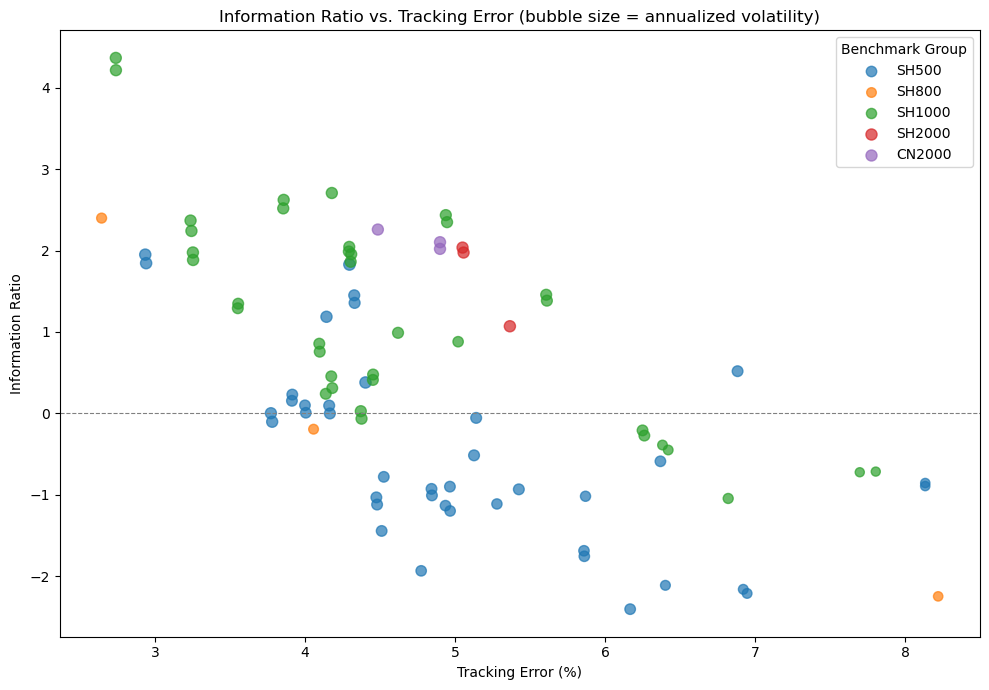

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 7))

groups = master_scorecard["benchmark_group"].unique()
colors = plt.cm.tab10.colors

for i, group in enumerate(groups):
    subset = master_scorecard[master_scorecard["benchmark_group"] == group]
    ax.scatter(
        subset["tracking_error_pct"],
        subset["information_ratio"],
        s=subset["ann_vol_pct"] * 3,  # bubble size ~ annualized volatility
        alpha=0.7,
        color=colors[i % len(colors)],
        label=group,
    )

ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_xlabel("Tracking Error (%)")
ax.set_ylabel("Information Ratio")
ax.set_title("Information Ratio vs. Tracking Error (bubble size = annualized volatility)")
ax.legend(title="Benchmark Group")

plt.tight_layout()
plt.savefig("fund_ir_vs_te_scatter.png", dpi=150)
plt.show()

/var/folders/y_/tfwy_qss7ls6y3ljn8tfdxjm0000gp/T/ipykernel_27830/2531526661.py:8: UserWarning: Glyph 26131 (\N{CJK UNIFIED IDEOGRAPH-6613}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/y_/tfwy_qss7ls6y3ljn8tfdxjm0000gp/T/ipykernel_27830/2531526661.py:8: UserWarning: Glyph 26041 (\N{CJK UNIFIED IDEOGRAPH-65B9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/y_/tfwy_qss7ls6y3ljn8tfdxjm0000gp/T/ipykernel_27830/2531526661.py:8: UserWarning: Glyph 36798 (\N{CJK UNIFIED IDEOGRAPH-8FBE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/y_/tfwy_qss7ls6y3ljn8tfdxjm0000gp/T/ipykernel_27830/2531526661.py:8: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/y_/tfwy_qss7ls6y3ljn8tfdxjm0000gp/T/ipykernel_27830/2531526661.py:8: UserWarning: Glyph 35777 (\N{CJK UNIFIED IDEOGRAPH-8BC1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/y_/tfwy_qss7

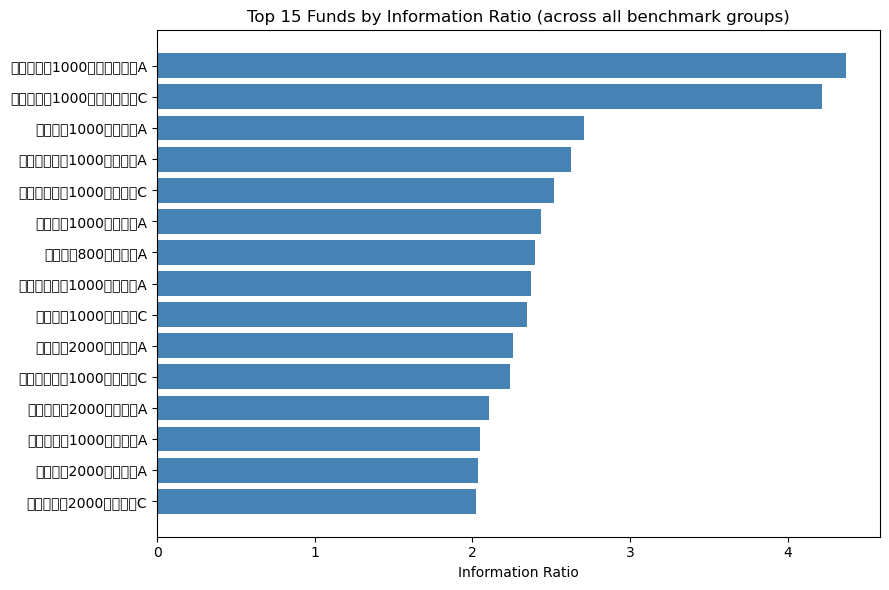

In [17]:
top15 = master_scorecard.sort_values("information_ratio", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top15["fund_name"], top15["information_ratio"], color="steelblue")
ax.invert_yaxis()
ax.set_xlabel("Information Ratio")
ax.set_title("Top 15 Funds by Information Ratio (across all benchmark groups)")
plt.tight_layout()
plt.savefig("fund_top15_ir_bar.png", dpi=150)
plt.show()